<div style='font-size:14px'>we spent entire last setion in cleaning job_skill column now we will visualise and see wht are the top skills req for Data analyst and this can be done through using explode method for further clean up

<div style='font-size:14px'>let say for eg. we need to calculate the value count of each skill so it will be difficult in list format to calculate it like if we run value_count on job_skill column then it will throw error mainly due to the fact that the list is not hashable in order to actuall do this u could use some loops or list comprehension maybe but the loop code will be long so we will run .explode method so it will explode out and make an individual tuple for each skill and then we can count it

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import numpy as np
import ast

# Loading Data set
dataset= load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [ ]:
df[['job_title_short','job_skills']].head().explode(column='job_skills')

In [ ]:
help(df.explode)

In [18]:
df_exploded = df.explode('job_skills')

In [ ]:
df_exploded['job_skills'].value_counts()

job_skills
sql            384849
python         380909
aws            145381
azure          132527
r              130892
                ...  
msaccess            1
visualbasic         1
gtx                 1
wimi                1
rocketchat          1
Name: count, Length: 252, dtype: int64

In [ ]:
df_exploded['job_skills'].value_counts().head(10).plot(kind='bar')

<div style='font-size:14px'>we are looking individually skills for all job title now i want to grp them not only by their skill count but also by that job title short column 

In [22]:
df_exploded.groupby(['job_skills','job_title_short']).size()

job_skills  job_title_short          
airflow     Business Analyst               318
            Cloud Engineer                 260
            Data Analyst                  2002
            Data Engineer                25505
            Data Scientist                3915
                                         ...  
zoom        Machine Learning Engineer       46
            Senior Data Analyst             86
            Senior Data Engineer           122
            Senior Data Scientist           79
            Software Engineer              229
Length: 2256, dtype: int64

In [24]:
skills_count = df_exploded.groupby(['job_title_short','job_skills']).size()
type(skills_count)

pandas.core.series.Series

<div style='font-size:14px'>now if we see type of this it will be series and plotting series is lil long than a df so we will convert it to df

In [ ]:
df_skills_count = skills_count.reset_index(name='skill_count')
type(df_skills_count) 

pandas.core.frame.DataFrame

<div style='font-size:14px'>next we need to sort these values and sorting the values by skill count is going to be necessary so whenever we are visualising it and only showing top 10 results  

In [ ]:
df_skills_count = df_skills_count.sort_values(by='skill_count',ascending=False)
df_skills_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


<div style='font-size:14px'>we're going to go fie=rst and jst plot data analyst basically the top 10 skills for DA

<Axes: ylabel='job_skills'>

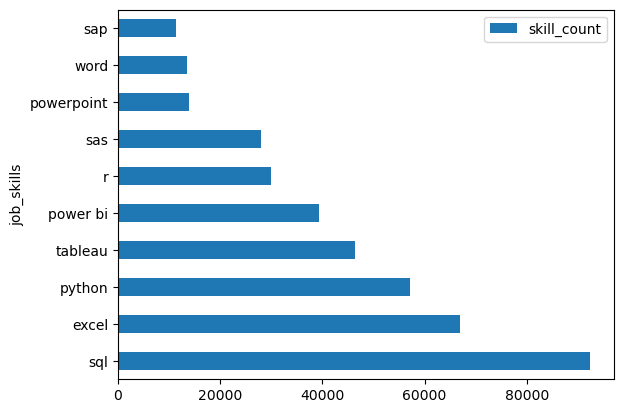

In [36]:
job_title = 'Data Analyst'
top_skills = 10

df_skill_final = df_skills_count[df_skills_count['job_title_short']== job_title].head(top_skills)

df_skill_final.plot(kind='barh',x='job_skills',y='skill_count')

<div style='font-size:14px'>now prblm with horizontal barcharts which we already saw before also is the order in which it plots it strts plotting at the bottom left and corner and then works upward from there so actually we need to reverse the axis so we can do the sort_value asc true and then take tail instead of head but another better option is in matplotlib has a method for inverting the y axis .invert_yaxis but the one more learning we need to go through before implementing this method is the fact that this method runs on the axis which in order to get axes we need to run .gca method first which is used to get the current axes 

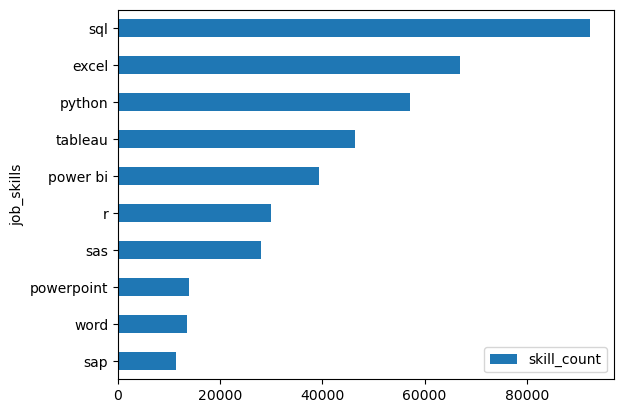

In [38]:
df_skill_final.plot(kind='barh',x='job_skills',y='skill_count')
plt.gca().invert_yaxis()

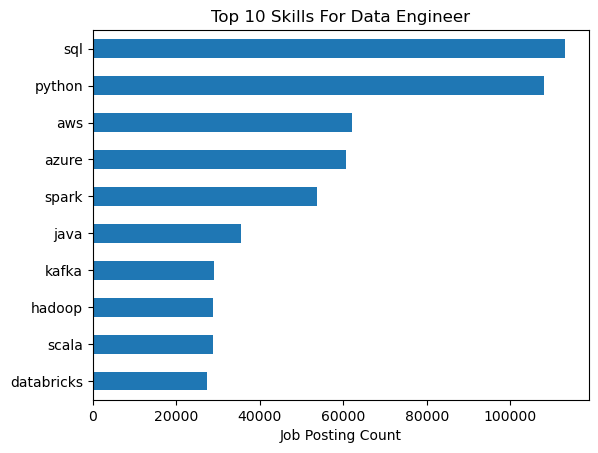

In [41]:
job_title = 'Data Engineer'
top_skills = 10

df_skill_final = df_skills_count[df_skills_count['job_title_short']== job_title].head(top_skills)

df_skill_final.plot(kind='barh',x='job_skills',y='skill_count')
plt.gca().invert_yaxis()
plt.title(f'Top {top_skills} Skills For {job_title}')
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.legend().set_visible(False)